In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip chest_xray.zip

Archive:  chest_xray.zip
   creating: chest_xray/
   creating: chest_xray/test/
   creating: chest_xray/test/NORMAL/
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-0988-0001.jpeg  
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-0989-0001.jpeg  
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-0992-0001.jpeg  
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-0993-0001.jpeg  
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-0994-0001.jpeg  
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-0995-0001-0001.jpeg  
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-0995-0001-0002.jpeg  
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-0995-0001.jpeg  
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-0997-0001.jpeg  
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-0998-0001.jpeg  
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-0999-0001.jpeg  
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-1001-0001.jpeg  
  inflating: chest_xray/test/NORMAL/NORMAL2-IM-1002-0001.jpeg  
  inflating: chest_xray/test/NORMAL/NORMA

In [ ]:
cd chest_xray/

/content/chest_xray


In [ ]:
ls

test/  train/


In [ ]:
cd train/

/content/chest_xray/train


In [ ]:
ls

NORMAL/  PNEUMONIA/


In [ ]:
!ls NORMAL | wc -l
!ls PNEUMONIA | wc -l

1260
1260


In [ ]:
!ls ../train/NORMAL | wc -l
!ls ../train/PNEUMONIA | wc -l
!ls ../test/NORMAL | wc -l
!ls ../test/PNEUMONIA | wc -l

1260
1260
315
315


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 224
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_dir = '.' # Current directory is /content/chest_xray/train
test_dir = '../test' # Relative path to /content/chest_xray/test

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="binary"
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)

Found 2520 images belonging to 2 classes.
Found 630 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    MaxPooling2D(),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(),

    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(1,activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_gen,
    epochs=15,
    validation_data=test_gen
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 353s 4s/step - accuracy: 0.6267 - loss: 0.7128 - val_accuracy: 0.8984 - val_loss: 0.2531
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 346s 4s/step - accuracy: 0.8672 - loss: 0.3120 - val_accuracy: 0.9238 - val_loss: 0.2290
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 336s 4s/step - accuracy: 0.8937 - loss: 0.2593 - val_accuracy: 0.9254 - val_loss: 0.1965
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 348s 4s/step - accuracy: 0.9122 - loss: 0.2355 - val_accuracy: 0.9222 - val_loss: 0.2012
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 338s 4s/step - accuracy: 0.9085 - loss: 0.2310 - val_accuracy: 0.9238 - val_loss: 0.1991
Epoch 6/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 415s 5s/step - accuracy: 0.9195 - loss: 0.2203 - val_accuracy: 0.9317 - val_loss: 0.1789
Epoch 7/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 370s 5s/step - accuracy: 0.9141 - loss: 0.2225 - val_accuracy: 0.9317 - val_loss: 0.1923
Epoch 8/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 343s 4s/step - accuracy: 0.9352 - loss: 0.1687 - val_accuracy: 0.9175 - v

In [ ]:
model.save('/content/drive/MyDrive/models/CNN_large_80_20_bs32_15ep.h5')

In [ ]:
import os

results_path = "/content/drive/MyDrive/experiment_results/L_CNN_large_80_20"
os.makedirs(results_path, exist_ok=True)

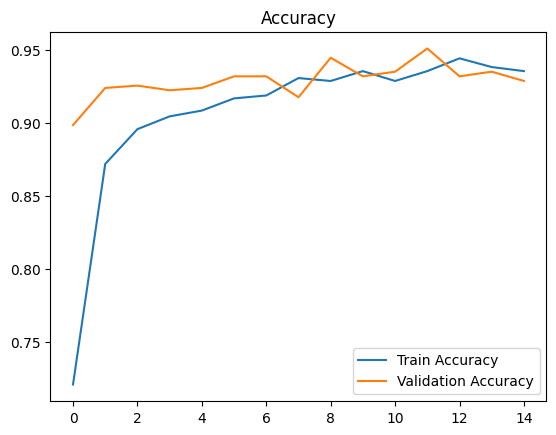

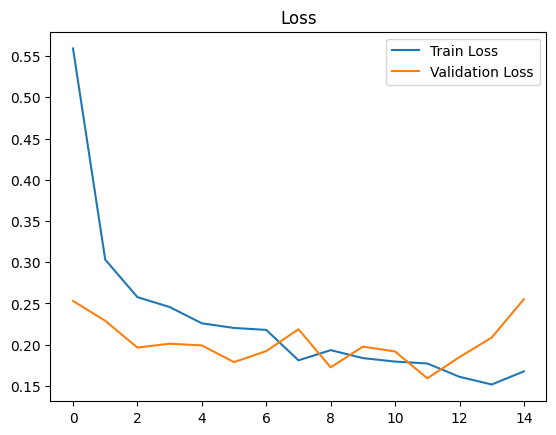

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],label="Train Accuracy")
plt.plot(history.history['val_accuracy'],label="Validation Accuracy")
plt.legend()
plt.title("Accuracy")
plt.savefig("/content/L_CNN_accuracy_80_20.png")
plt.savefig(results_path + "/L_CNN_accuracy_plot_80_20.png")
plt.show()

plt.plot(history.history['loss'],label="Train Loss")
plt.plot(history.history['val_loss'],label="Validation Loss")
plt.legend()
plt.title("Loss")
plt.savefig("/content/L_CNN_loss_80_20.png")
plt.savefig(results_path + "/L_CNN__loss_plot_80_20.png")
plt.show()

In [ ]:
from google.colab import files

# Download accuracy plot
files.download('/content/L_CNN_accuracy_80_20.png')

# Download loss plot
files.download('/content/L_CNN_loss_80_20.png')

# Download classification report
files.download('/content/L_CNN_classification_report_80_20.txt')

# Download confusion matrix
files.download('/content/L_CNN_confusion_matrix_80_20.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

pred = model.predict(test_gen)
pred = (pred > 0.5).astype(int)

cm = confusion_matrix(test_gen.classes, pred)
print(cm)

20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step
[[304  11]
 [ 34 281]]


In [ ]:
print(classification_report(
    test_gen.classes,
    pred,
    target_names=["Normal","Pneumonia"]
))

              precision    recall  f1-score   support

      Normal       0.90      0.97      0.93       315
   Pneumonia       0.96      0.89      0.93       315

    accuracy                           0.93       630
   macro avg       0.93      0.93      0.93       630
weighted avg       0.93      0.93      0.93       630



In [ ]:
report = classification_report(
    test_gen.classes,
    pred,
    target_names=["Normal","Pneumonia"]
)

with open("/content/L_CNN_classification_report_80_20.txt","w") as f:
    f.write(report)

print("Report saved!")

Report saved!


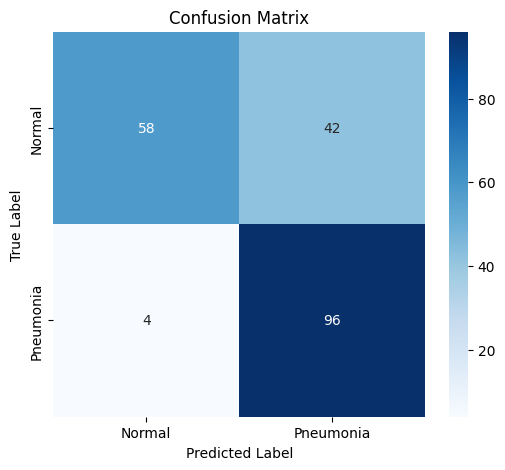

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Your confusion matrix values
cm = np.array([[58, 42],
               [4, 96]])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            cmap="Blues",
            xticklabels=["Normal", "Pneumonia"],
            yticklabels=["Normal", "Pneumonia"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

# Save image
plt.savefig("/content/L_CNN_confusion_matrix_80_20.png")
plt.show()


In [ ]:
from sklearn.metrics import f1_score

report = classification_report(test_gen.classes, pred, target_names=['Normal','Pneumonia'])
weighted_f1 = f1_score(test_gen.classes, pred, average='weighted')

In [ ]:
with open(results_path + "/L_CNN_classification_report_80_20.txt", "w") as f:
    f.write(report)
    f.write("\nWeighted F1 Score: " + str(weighted_f1))

In [ ]:
final_val_acc = history.history['val_accuracy'][-1]
final_val_loss = history.history['val_loss'][-1]